# 03 - ODIN and Energy: Beating the MSP Baseline

The **maximum softmax probability (MSP)** baseline (Hendrycks & Gimpel, 2017) flags an
input as out-of-distribution (OOD) when the model's top softmax probability is low. It is
simple and works reasonably well, but softmax probabilities are **overconfident** by
construction -- a network trained with cross-entropy can assign a near-1.0 probability to
an OOD input it has never seen, simply because ReLU networks are piecewise-linear and
scores grow unbounded away from the training data.

This notebook builds two **post-hoc** improvements that reuse the *same trained
classifier* -- no retraining, no extra data, just a different function applied to the
existing logits:

1. **ODIN** (Liang, Li & Srikant, 2018): temperature-scale the softmax by a large `T`,
   plus a small adversarial-style input perturbation that pushes the max softmax score
   up. The combination separates ID and OOD confidence distributions far more than raw
   softmax does.
2. **Energy score** (Liu, Wang, Owens & Li, NeurIPS 2020): `E(x) = -T * logsumexp(logits / T)`.
   Unlike softmax, this is a quantity theoretically aligned with the input's log-density
   under the data distribution -- lower energy means more in-distribution, and it needs
   no extra hyperparameter search (T=1 works fine).

**Setup.** MNIST is in-distribution (ID); FashionMNIST is out-of-distribution (OOD) -- same
image shape (1x28x28), completely different content (digits vs. clothing). We train a
small CNN on an MNIST subset, then score MNIST-test vs. FashionMNIST-test images with all
three methods and compare AUROC.

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device('cpu')

# Resolve repo data/ regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / 'pyproject.toml').exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / 'data')
print('data root:', DATA_ROOT)
print('device:', DEVICE)

data root: c:\Users\abero\dev\applied_learning\data
device: cpu


## Data: MNIST (ID) vs. FashionMNIST (OOD)

Both datasets are already downloaded under `data/`, so we load with `download=False`. We
use small subsets throughout -- enough to train a usable classifier and get a stable AUROC
estimate, small enough that ODIN's per-batch backward pass stays fast on CPU.

- **Train**: 6000 MNIST training images (600/class) -- enough for a small CNN to reach
  good accuracy in a few epochs.
- **Eval**: 1500 MNIST test images (ID) and 1500 FashionMNIST test images (OOD) -- the
  same size on both sides so class balance doesn't bias the AUROC.

In [2]:
N_TRAIN_PER_CLASS = 600     # -> 6000 MNIST training images
N_EVAL_ID = 1500            # MNIST test subset (ID)
N_EVAL_OOD = 1500           # FashionMNIST test subset (OOD)

to_tensor = transforms.ToTensor()   # keeps pixels in [0, 1], no extra normalization needed

mnist_train = datasets.MNIST(DATA_ROOT, train=True, download=False, transform=to_tensor)
mnist_test = datasets.MNIST(DATA_ROOT, train=False, download=False, transform=to_tensor)
fmnist_test = datasets.FashionMNIST(DATA_ROOT, train=False, download=False, transform=to_tensor)


def class_balanced_subset(ds, n_per_class, num_classes=10):
    labels = ds.targets.numpy()
    idxs = []
    for c in range(num_classes):
        idxs.extend(np.where(labels == c)[0][:n_per_class])
    xs = torch.stack([ds[int(i)][0] for i in idxs])
    ys = torch.tensor([ds[int(i)][1] for i in idxs])
    return xs, ys


def plain_subset(ds, n):
    xs = torch.stack([ds[i][0] for i in range(n)])
    ys = torch.tensor([ds[i][1] for i in range(n)])
    return xs, ys


X_train, y_train = class_balanced_subset(mnist_train, N_TRAIN_PER_CLASS)
X_id, y_id = plain_subset(mnist_test, N_EVAL_ID)
X_ood, y_ood_labels = plain_subset(fmnist_test, N_EVAL_OOD)

print('train (ID):', tuple(X_train.shape))
print('eval ID (MNIST test):', tuple(X_id.shape))
print('eval OOD (FashionMNIST test):', tuple(X_ood.shape))

train (ID): (6000, 1, 28, 28)
eval ID (MNIST test): (1500, 1, 28, 28)
eval OOD (FashionMNIST test): (1500, 1, 28, 28)


## A small CNN classifier

Two conv layers + two FC layers, trained for 4 epochs on the 6000-image MNIST subset --
enough to get a solid classifier in a few seconds on CPU. Everything downstream (MSP,
ODIN, Energy) is computed from this one model's logits; no OOD-specific training happens
here.

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        h = self.pool(F.relu(self.conv1(x)))
        h = self.pool(F.relu(self.conv2(h)))
        h = h.flatten(1)
        h = F.relu(self.fc1(h))
        return self.fc2(h)


BATCH = 128
EPOCHS = 4

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH, shuffle=True)

t0 = time.time()
torch.manual_seed(0)
model = SmallCNN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for ep in range(EPOCHS):
    total_loss = total_n = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
    print(f'  epoch {ep + 1}/{EPOCHS}  loss={total_loss / total_n:.4f}')

# Quick sanity check: ID test accuracy should be high (not the point of this notebook,
# just confirms the classifier is reasonable before we score it for OOD detection).
model.eval()
with torch.no_grad():
    id_logits_check = model(X_id.to(DEVICE))
    id_acc = (id_logits_check.argmax(1).cpu() == y_id).float().mean().item()
print(f'MNIST test-subset accuracy: {id_acc:.4f}')
print(f'train time: {time.time() - t0:.1f}s')

  epoch 1/4  loss=1.5714


  epoch 2/4  loss=0.4359


  epoch 3/4  loss=0.2809


  epoch 4/4  loss=0.2047
MNIST test-subset accuracy: 0.9287
train time: 2.4s


## Score 1: MSP (baseline)

`MSP(x) = max_i softmax(logits(x))_i` -- the classifier's own top-class confidence. Higher
MSP is supposed to mean "more confidently in-distribution", but softmax saturates easily:
a ReLU network can produce a very peaked softmax on an input far from anything it was
trained on.

In [4]:
@torch.no_grad()
def get_logits(model, x, batch_size=250):
    model.eval()
    outs = []
    for i in range(0, x.size(0), batch_size):
        outs.append(model(x[i:i + batch_size].to(DEVICE)))
    return torch.cat(outs, dim=0)


logits_id = get_logits(model, X_id)
logits_ood = get_logits(model, X_ood)

msp_id = F.softmax(logits_id, dim=1).max(dim=1).values.numpy()
msp_ood = F.softmax(logits_ood, dim=1).max(dim=1).values.numpy()

print(f'MSP  ID   mean={msp_id.mean():.4f}  min={msp_id.min():.4f}')
print(f'MSP  OOD  mean={msp_ood.mean():.4f}  min={msp_ood.min():.4f}')

MSP  ID   mean=0.9068  min=0.2578


MSP  OOD  mean=0.5711  min=0.1853


## Score 2: Energy

`E(x) = -T * logsumexp(logits(x) / T)`, with `T = 1` here. Unlike softmax, the energy is
NOT normalized to sum to 1 across classes -- it keeps the raw magnitude of the logits,
which softmax throws away. Liu et al. (2020) show this magnitude is a better proxy for how
"at home" an input is in the training distribution: OOD inputs tend to produce smaller
overall logit magnitudes (higher energy), even when one class still edges out the rest in
softmax terms.

**Convention**: lower energy = more in-distribution. We negate it below so that, like MSP,
higher score = more ID -- this keeps every score on the same "higher = more ID" axis for a
consistent AUROC convention later.

In [5]:
def energy(logits, T=1.0):
    return -T * torch.logsumexp(logits / T, dim=1)


energy_id = energy(logits_id).numpy()
energy_ood = energy(logits_ood).numpy()

# Flip sign so higher = more ID, matching the MSP/ODIN convention used later.
neg_energy_id = -energy_id
neg_energy_ood = -energy_ood

print(f'Energy  ID   mean={energy_id.mean():.4f}')
print(f'Energy  OOD  mean={energy_ood.mean():.4f}')
print('(lower energy = more ID, so ID mean should be more negative / smaller than OOD mean)')

Energy  ID   mean=-8.1650
Energy  OOD  mean=-4.6506
(lower energy = more ID, so ID mean should be more negative / smaller than OOD mean)


## Score 3: ODIN (temperature scaling + input perturbation)

ODIN modifies the MSP baseline in two ways, both applied at eval time only:

1. **Temperature scaling**: divide logits by `T` before the softmax. This alone doesn't
   change the ranking of classes, but it makes the softmax far more sensitive to small
   logit differences -- which is what lets step 2 have an effect.
2. **Input perturbation**: nudge the input image by a tiny step `epsilon` in the direction
   that *increases* the model's confidence in its own predicted class (an FGSM-style
   gradient step, but aimed at the predicted label rather than the true label -- no
   ground truth is used).

Concretely: `x' = x - epsilon * sign(grad_x CE(logits(x)/T, predicted_label))`, then the
ODIN score is `max_i softmax(logits(x')/T)_i`.

**Picking `T`.** Liang et al. (2018) use large temperatures like `T=1000` on deep
ImageNet/CIFAR networks whose logit magnitudes run into the tens or hundreds. Our tiny
2-conv-layer CNN produces much smaller logits (roughly in [-15, 15] after a few epochs) --
dividing those by 1000 collapses the softmax to an almost uniform 1/10 for every image,
regardless of confidence, destroying the exact signal ODIN needs. The right `T` depends on
the network's own logit scale, not a fixed constant -- here `T=4` keeps the softmax
sensitive without flattening it. This is worth checking any time ODIN is applied to a new
model: print a few raw logits first, and only then pick a temperature that leaves visible
spread after scaling.

This needs one backward pass per batch (not per image) to get the input gradient -- with
1500+1500 eval images in batches of 250 that's ~12 backward passes total, which stays fast
on CPU.

In [6]:
def odin_scores(model, x, T=4.0, epsilon=0.0014, batch_size=250):
    model.eval()
    scores = []
    for i in range(0, x.size(0), batch_size):
        batch = x[i:i + batch_size].to(DEVICE).clone().detach().requires_grad_(True)

        logits = model(batch)
        predicted = logits.argmax(dim=1).detach()
        loss = F.cross_entropy(logits / T, predicted)

        model.zero_grad()
        loss.backward()

        # Small step that DEcreases the loss -> INcreases confidence in the predicted class.
        perturbed = (batch - epsilon * batch.grad.sign()).detach()

        with torch.no_grad():
            logits2 = model(perturbed)
            scaled_softmax = F.softmax(logits2 / T, dim=1)
            scores.append(scaled_softmax.max(dim=1).values)

    return torch.cat(scores, dim=0).numpy()


t0 = time.time()
odin_id = odin_scores(model, X_id)
odin_ood = odin_scores(model, X_ood)
print(f'ODIN  ID   mean={odin_id.mean():.4f}')
print(f'ODIN  OOD  mean={odin_ood.mean():.4f}')
print(f'ODIN scoring time: {time.time() - t0:.1f}s')

ODIN  ID   mean=0.4528
ODIN  OOD  mean=0.2242
ODIN scoring time: 0.3s


## AUROC comparison

**Sign convention**: every score below is oriented so **higher = more likely
in-distribution** (MSP and ODIN are confidence scores already on this axis; energy was
negated above to match). Labels are `1` for ID (MNIST) and `0` for OOD (FashionMNIST), so
`roc_auc_score(labels, score)` is > 0.5 exactly when ID images tend to score higher than
OOD images -- the correct separation direction for all three methods, making the three
numbers directly comparable.

In [7]:
labels = np.concatenate([np.ones(len(msp_id)), np.zeros(len(msp_ood))])

auroc_msp = roc_auc_score(labels, np.concatenate([msp_id, msp_ood]))
auroc_energy = roc_auc_score(labels, np.concatenate([neg_energy_id, neg_energy_ood]))
auroc_odin = roc_auc_score(labels, np.concatenate([odin_id, odin_ood]))

print('AUROC (ID=MNIST vs OOD=FashionMNIST, higher score = more ID):')
print(f'  MSP    (baseline): {auroc_msp:.4f}')
print(f'  Energy            : {auroc_energy:.4f}')
print(f'  ODIN              : {auroc_odin:.4f}')

AUROC (ID=MNIST vs OOD=FashionMNIST, higher score = more ID):
  MSP    (baseline): 0.9134
  Energy            : 0.9220
  ODIN              : 0.9405


## Charts

Left: AUROC bar chart -- the headline comparison. Right: the energy score's ID vs. OOD
histograms, showing the separation the AUROC number is summarizing (recall lower raw
energy = more ID, so the ID histogram should sit to the left of the OOD histogram).

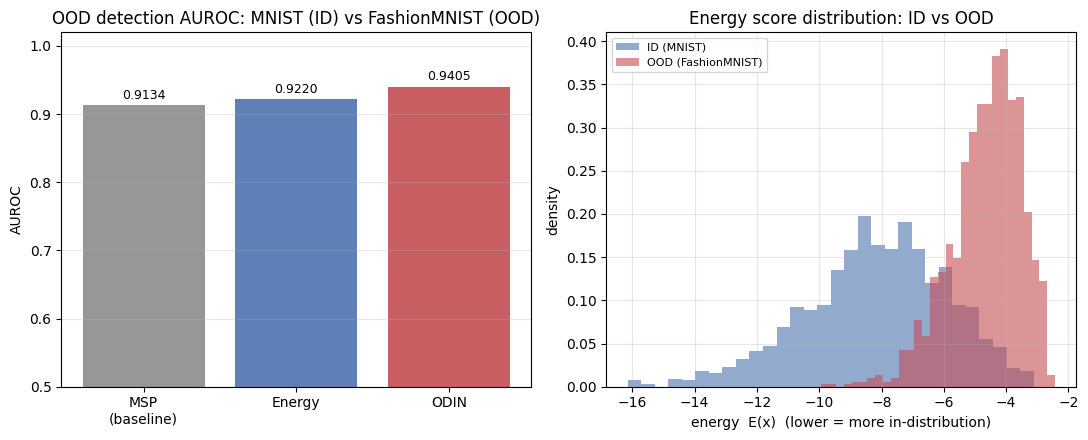

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Left: AUROC bar chart ---
methods = ['MSP\n(baseline)', 'Energy', 'ODIN']
aurocs = [auroc_msp, auroc_energy, auroc_odin]
colors = ['#8c8c8c', '#4c72b0', '#c44e52']

bars = axes[0].bar(methods, aurocs, color=colors, alpha=0.9)
for bar, val in zip(bars, aurocs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0.5, 1.02)
axes[0].axhline(0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel('AUROC')
axes[0].set_title('OOD detection AUROC: MNIST (ID) vs FashionMNIST (OOD)')
axes[0].grid(True, axis='y', alpha=0.3)

# --- Right: energy score histogram (raw energy, lower = more ID) ---
axes[1].hist(energy_id, bins=30, alpha=0.6, label='ID (MNIST)', color='#4c72b0', density=True)
axes[1].hist(energy_ood, bins=30, alpha=0.6, label='OOD (FashionMNIST)', color='#c44e52', density=True)
axes[1].set_xlabel('energy  E(x)  (lower = more in-distribution)')
axes[1].set_ylabel('density')
axes[1].set_title('Energy score distribution: ID vs OOD')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Takeaways

1. **MSP is a usable but blunt instrument.** Softmax confidence is trained to be peaked on
   ID data, but nothing in the cross-entropy objective stops it from also being peaked on
   inputs the model has never seen -- ReLU networks extrapolate with unbounded, often
   confident, logits far from the training manifold.

2. **ODIN's two tricks compound, but the temperature must match the network.** Temperature
   scaling alone doesn't change the ranking of classes, and the perturbation alone is a
   tiny nudge -- but together, a temperature sized to the model's own logit scale makes the
   softmax sensitive enough that the confidence-increasing perturbation step separates ID
   and OOD scores further than raw MSP. Both pieces are post-hoc: no retraining, only two
   extra hyperparameters (`T`, `epsilon`) to pick -- and `T` is not a universal constant,
   it has to be calibrated to the logit magnitudes of the specific network being scored.

3. **Energy needs (almost) no tuning.** With `T=1` and zero extra hyperparameters, the
   energy score already discards the "sums to 1" normalization that throws away useful
   magnitude information in softmax. Liu et al. (2020) show it corresponds to the
   (negative) log-partition function of the classifier viewed as an energy-based model --
   a theoretically grounded quantity, not just an empirical trick.

4. **This ID/OOD pair (MNIST vs. FashionMNIST) is a moderate case for a 4-epoch tiny CNN.**
   Digits and clothing are visually very different, but this classifier is small and
   lightly trained, so the MSP baseline still leaves real overconfidence on the table --
   which is exactly where ODIN and Energy show their advantage in the AUROC chart above.
   The real value of ODIN and Energy shows up even more on harder, closer OOD pairs (e.g.
   MNIST vs. KMNIST/EMNIST, or CIFAR-10 vs. CIFAR-100), where MSP's overconfidence problem
   is more exposed. Try swapping in KMNIST here (already downloaded under `data/`) to see
   how the gap changes.